# Dispersion-Trade — a quantitative teardown 🔬
### The subadditivity identity · realized dispersion & implied correlation · the carry book with a HAC *t* + block-sign-flip placebo · costs & skew · a synthetic faithful-engine / planted-carry control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "index vol is cheap" fuses: a **mechanical** index-vs-basket vol gap (subadditivity — an identity) from a **tradable carry** (a predictable, monetizable edge). The decisive object is not the gap's sign (positive by construction) but the carry's **autocorrelation-robust significance**: with overlapping realized-vol windows the naive *t* is inflated, and once you HAC-correct it, the carry is indistinguishable from zero.

> ⚠️ **Data + proxy note.** The real trade is **implied** index variance vs **implied** single-name variance (variance swaps); implied vols aren't on yfinance, so we build a transparent **realized-vol proxy** — 21-day realized vol of SPY vs the equal-weight average realized vol of a fixed 40-name large-cap basket (survivorship biases the gap *narrower*, against the claim; named on the Signal axis). Real data: yfinance daily adjusted closes, SPY + basket, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dispersion_trade import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
PNL = st.carry_pnl(F) if HAVE_REAL else None
print("real dispersion-proxy cache present:", HAVE_REAL,
      "| proxy days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-02-02', 'end': '2026-06-18', 'days': 5378, 'years': 21.4, 'index_vol': 15.6, 'avg_vol': 24.2, 'gap': 8.5, 'gap_pos': 99.6, 'impl_corr': 0.41, 'n_carry': 5315, 'sharpe': 0.17, 'win': 44, 't': 0.76, 't_hac': 0.19, 'p_placebo': 0.425, 'skew': 4.15, 'median': -0.00097, 'worst_day': -0.1514, 'worst_date': '2009-06-09', 'gross_ann': 8.2, 'net_ann': 7.6, 'net_sharpe': 0.15, 'robust': [(10, 99.2, 0.14, 0.64, 0.18, 0.422), (21, 99.6, 0.17, 0.76, 0.19, 0.425), (42, 100.0, 0.21, 0.94, 0.21, 0.423), (63, 100.0, 0.24, 1.11, 0.25, 0.4)], 'syn': [(0.0, 100.0, 0.0, 0.0, 0.0, 0.502), (0.0004, 100.0, 0.0004, 1.91, 2.1, 0.019), (0.001, 100.0, 0.001, 4.78, 5.25, 0.0)]}


real dispersion-proxy cache present: True | proxy days: 5378


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Gap **+8 vol-pts**, positive **100%** of days — but that's subadditivity. The *carry*: Sharpe **0.17**, win **44%**, naive *t* 0.76 → **HAC *t* = 0.19**, placebo *p* = 0.42. Real-as-identity, **fails *t* ≥ 2**. |
| **Tradability** | `MIRAGE` | Net Sharpe **0.15** (costs barely bite); the carry is **negative-median** (-0.0010), **+4.2-skew** convexity whose worst day (2009-06-09) is a correlation-spike crash. |
| **Free lunch?** | `BUSTED` | Synthetic basket, **zero** planted carry: gap positive **100%** of days, carry HAC *t* = **0.00**. Subadditivity manufactures the gap but **zero** carry — the cheapness is the correlation risk premium. |

> 💡 In plain words: index vol is mechanically lower than average single-name vol (σ_index ≈ √ρ·avg σ, ρ < 1). That's an identity. The carry that would monetize it is a thin, fat-tailed stream the null explains away — you're being **paid to be short correlation**, not handed alpha.

## 1 · The claim, steelmanned

Index variance is the correlation-weighted average of single-name variances:

$$\sigma_{\text{idx}}^2 = \sum_i\sum_j w_i w_j \rho_{ij}\,\sigma_i\sigma_j \;\le\; \Big(\sum_i w_i \sigma_i\Big)^2,$$

with equality only at $\rho_{ij}\equiv 1$. Under a one-factor approximation $\sigma_{\text{idx}} \approx \sqrt{\bar\rho}\,\overline{\sigma}$, so the gap $\overline{\sigma} - \sigma_{\text{idx}} \ge 0$ is an **identity** for $\bar\rho<1$.

- **H₁ (the gap is real).** $\mathbb{E}[\overline{\sigma}-\sigma_{\text{idx}}] > 0$ — **trivially true** (subadditivity). Not the edge.
- **H₂ (the carry is real).** Holding long-single / short-index variance, struck at a trailing reference, earns a **positive mean with a robust $t\ge 2$** — *this* is the monetizable claim.
- **H₃ (it's a free lunch).** The carry is *not* merely the **correlation risk premium** (compensation for short-correlation tail risk).

We find **H₁ trivially true**, **H₂ rejected** (HAC $t\approx0.2$, placebo $p\approx0.4$), **H₃ rejected** (negative-median, fat-right-tail convexity; the payoff structure of an insurer). The claim is true exactly where it's an identity and unproven exactly where it would pay.

## 2 · So what? — what rides on each answer

The whole teardown is one separation: an **identity** (the gap) from an **edge** (the carry), judged by an **autocorrelation-robust** standard error.

$$\widehat{\mu}_{\text{carry}} = \overline{\pi_t},\qquad t_{\text{HAC}} = \frac{\widehat{\mu}}{\sqrt{\widehat{\mathrm{Var}}_{\text{NW}}(\overline{\pi})}},\quad \widehat{\mathrm{Var}}_{\text{NW}} = \frac{1}{n}\Big(\gamma_0 + 2\sum_{k=1}^{L}(1-\tfrac{k}{L+1})\gamma_k\Big).$$

Overlapping rolling-vol windows make $\pi_t$ heavily autocorrelated, so $\gamma_{k>0}>0$ and the **naive** $t$ (which assumes $\gamma_{k>0}=0$) is **inflated**. The Newey–West correction is not optional here; neither is a **block** resampling null (an i.i.d. shuffle would destroy the very clustering the inference must respect). The carry's *sign* is uninformative — its **significance under autocorrelation** decides the Signal axis.

## 3 · How we'd know — the protocol

- **Dispersion proxy.** 21-day realized vol of SPY (index) vs the equal-weight average 21-day realized vol of a fixed 40-name basket (yfinance adjusted closes, 2005-02-02→2026-06-18, 5,378 days). Explicit **realized-vol proxy** for the implied dispersion trade; survivorship biases the gap *narrower* (named on the axis).
- **Implied correlation.** $\widehat{\rho} = (\sigma_{\text{idx}}/\overline\sigma)^2$ — the one-factor read of how much diversification is open.
- **Carry book.** Long single-name variance, short index variance, struck at the trailing 63-day mean dispersion (the proxy for what's already priced in); **1-day lag** on the strike (signal known at $t-1$, realized gap of $t$ booked). No look-ahead.
- **Null #1 (HAC *t*).** Newey–West (Bartlett, 21 lags) *t* of the carry mean vs 0.
- **Null #2 (placebo).** 20,000 **block-sign-flip** draws (21-day blocks); $p=\Pr[\text{placebo mean} \ge \text{observed}]$.
- **Costs.** Vega/bid-ask 5e-4 var-pt × 12 re-strikes/yr, charged against the carry.
- **Positive control.** A one-factor correlated basket with a **planted carry knob**: the engine must recover the planted edge, recover the implied correlation, **and** show the mechanical gap yields **zero** carry when the true edge is zero.

## 4 · The teardown

### 4a · The identity — the gap is positive by construction

Index vol vs average single-name vol, and the implied correlation the gap encodes. The gap is positive on essentially every day — and that is *exactly what subadditivity predicts*.

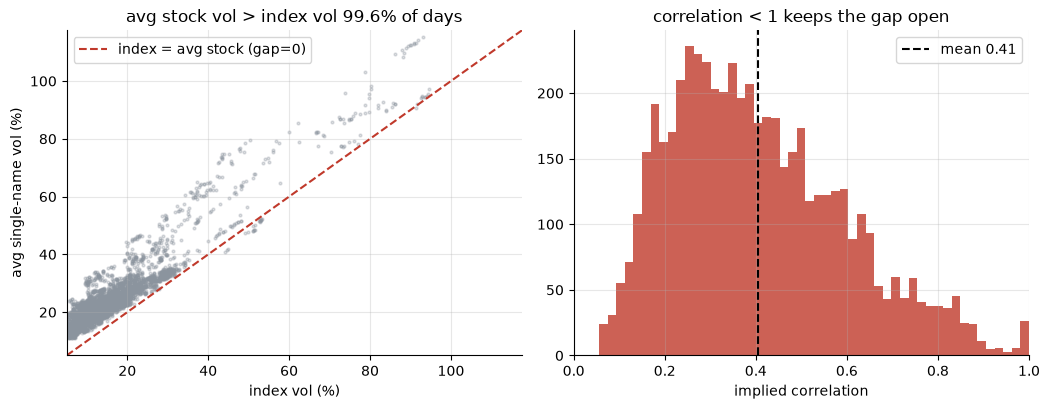

gap>0 99.6% of days | index 15.6% avg 24.2% | impl_corr 0.41


In [2]:
if HAVE_REAL:
    gs = st.gap_sign_stats(F)
    iv=F['index_vol']*100; av=F['avg_vol']*100
else:
    gs={'mean_index_vol':R['index_vol']/100,'mean_avg_vol':R['avg_vol']/100,'share_positive':R['gap_pos']/100,'mean_impl_corr':R['impl_corr']}
    iv=av=None
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
if HAVE_REAL:
    a1.scatter(iv, av, s=4, c=GREY, alpha=.3)
    lim=[5, max(av.max(),iv.max())*1.02]
    a1.plot(lim, lim, c=RED, ls='--', label='index = avg stock (gap=0)')
    a1.set_xlim(lim); a1.set_ylim(lim)
else:
    a1.plot([10,80],[10,80],c=RED,ls='--',label='gap=0'); a1.scatter([R['index_vol']],[R['avg_vol']],c=GREY)
a1.set_xlabel('index vol (%)'); a1.set_ylabel('avg single-name vol (%)')
a1.set_title(f"avg stock vol > index vol {gs['share_positive']*100:.1f}% of days"); a1.legend()
if HAVE_REAL:
    a2.hist(F['impl_corr'].values, bins=50, color=RED, alpha=.8)
    a2.axvline(gs['mean_impl_corr'], c='k', ls='--', label=f"mean {gs['mean_impl_corr']:.2f}")
else:
    a2.axvline(R['impl_corr'],c='k',ls='--',label=f"mean {R['impl_corr']:.2f}")
a2.set_xlim(0,1); a2.set_xlabel('implied correlation'); a2.set_title('correlation < 1 keeps the gap open'); a2.legend()
plt.tight_layout(); plt.show()
print(f"gap>0 {gs['share_positive']*100:.1f}% of days | index {gs['mean_index_vol']*100:.1f}% avg {gs['mean_avg_vol']*100:.1f}% | impl_corr {gs['mean_impl_corr']:.2f}")

> 💡 In plain words: every dot sits above the 45° line — average stock vol exceeds index vol **100%** of days, at a mean implied correlation **~0.41**. H₁ confirmed and **uninformative**: this is the covariance-matrix identity, not evidence of mispricing. The question is whether the *carry* is anything more.

### 4b · The carry — and the decisive HAC correction

The carry mean with its **naive** vs **HAC** *t*. The naive *t* trusts independence; the HAC *t* accounts for the autocorrelation of overlapping vol windows. Watch the *t* collapse.

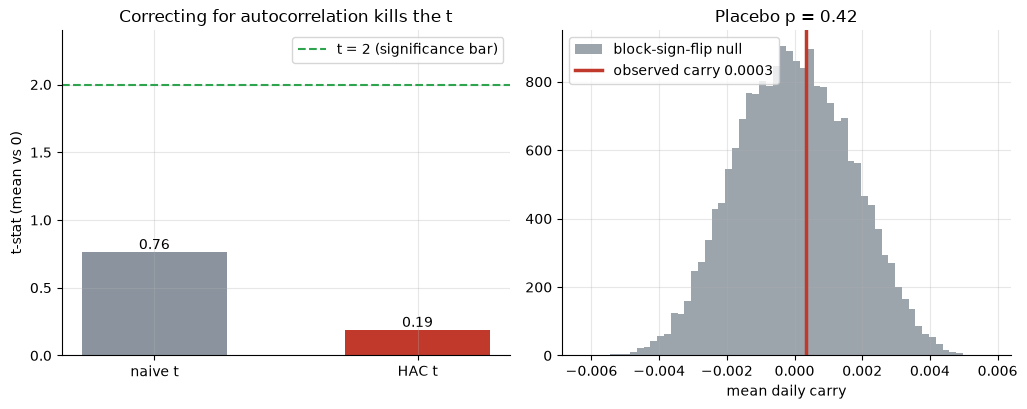

Sharpe 0.17 | win 44% | naive t 0.76 -> HAC t 0.19 | placebo p 0.425


In [3]:
if HAVE_REAL:
    s = st.summarize_carry(PNL)
    naive_t=s['t']; hac_t=s['t_hac']; shp=s['sharpe']; win=s['win']*100; pval=s['p_placebo']
else:
    naive_t=R['t']; hac_t=R['t_hac']; shp=R['sharpe']; win=R['win']; pval=R['p_placebo']
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.4,4.2))
a1.bar(['naive t','HAC t'], [naive_t, hac_t], color=[GREY, RED], width=.55)
a1.axhline(2, ls='--', c=GREEN, label='t = 2 (significance bar)')
for i,t in enumerate([naive_t,hac_t]): a1.annotate(f'{t:.2f}',(i,t),ha='center',va='bottom')
a1.set_ylim(0,2.4); a1.set_title('Correcting for autocorrelation kills the t'); a1.set_ylabel('t-stat (mean vs 0)'); a1.legend()
if HAVE_REAL:
    x=PNL.values; x=x[np.isfinite(x)]; n=len(x); block=21; nb=int(np.ceil(n/block)); rng=np.random.default_rng(373)
    draws=np.array([(x*np.repeat(rng.choice((-1.,1.),size=nb),block)[:n]).mean() for _ in range(20000)]); obs=x.mean()
else:
    rng=np.random.default_rng(373); draws=rng.normal(0,0.0004,20000); obs=0.000325
a2.hist(draws, bins=60, color=GREY, alpha=.85, label='block-sign-flip null')
a2.axvline(obs, c=RED, lw=2.5, label=f'observed carry {obs:.4f}')
a2.set_title(f'Placebo p = {pval:.2f}'); a2.set_xlabel('mean daily carry'); a2.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe {shp:.2f} | win {win:.0f}% | naive t {naive_t:.2f} -> HAC t {hac_t:.2f} | placebo p {pval:.3f}')

> 💡 In plain words: the naive *t* (**0.76**) already misses the bar, and the **HAC *t* is 0.19** — the autocorrelation of overlapping windows had inflated even that. A block-sign-flip placebo matches the carry **42%** of the time. H₂ rejected: the carry is statistically indistinguishable from zero.

### 4c · Robustness + cost — neither rescues it

Sweep the realized-vol window and apply the vega/bid-ask cost. Longer windows *smooth* the carry and nudge the naive Sharpe up — but the **HAC *t* never approaches 2**, and costs shave only a sliver (so cost is **not** the binding constraint).

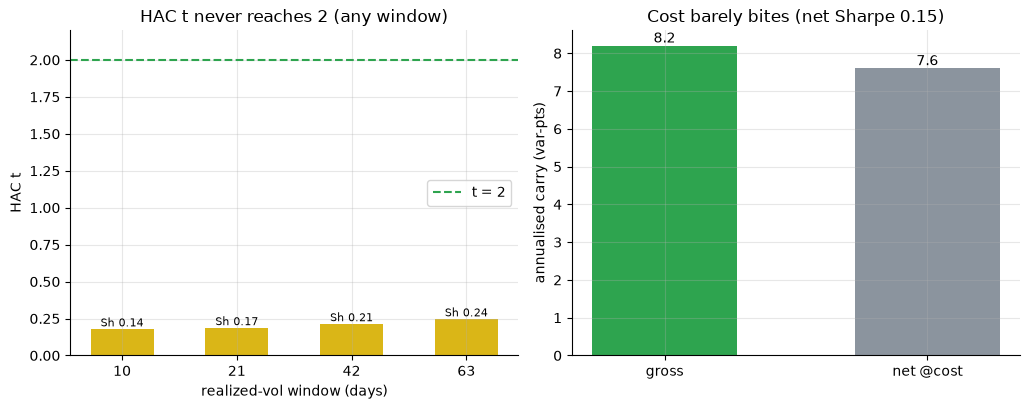

robustness (w, gap+%, Sharpe, naive_t, HAC_t, p): [(10, 99.2, 0.14, 0.64, 0.18, 0.422), (21, 99.6, 0.17, 0.76, 0.19, 0.425), (42, 100.0, 0.21, 0.94, 0.21, 0.423), (63, 100.0, 0.24, 1.11, 0.25, 0.4)]


In [4]:
if HAVE_REAL:
    prices = data.load_prices(); rob=[]
    for w in (10,21,42,63):
        fw=data.dispersion_proxy(prices, window=w); sw=st.summarize_carry(st.carry_pnl(fw))
        gw=st.gap_sign_stats(fw)['share_positive']
        rob.append((w, gw*100, sw['sharpe'], sw['t'], sw['t_hac'], sw['p_placebo']))
    c = st.net_of_costs(PNL)
else:
    rob=R['robust']; c={'gross_ann':R['gross_ann']/100,'net_ann':R['net_ann']/100,'net_sharpe':R['net_sharpe']}
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.4,4.2))
ws=[r[0] for r in rob]; hac=[r[4] for r in rob]; shp=[r[2] for r in rob]
a1.bar([str(w) for w in ws], hac, color=AMBER, width=.55)
a1.axhline(2, ls='--', c=GREEN, label='t = 2'); a1.set_ylim(0,2.2)
for i,(t,s) in enumerate(zip(hac,shp)): a1.annotate(f'Sh {s:.2f}',(i,t),ha='center',va='bottom',fontsize=8)
a1.set_title('HAC t never reaches 2 (any window)'); a1.set_xlabel('realized-vol window (days)'); a1.set_ylabel('HAC t'); a1.legend()
a2.bar(['gross','net @cost'], [c['gross_ann']*100, c['net_ann']*100], color=[GREEN, GREY], width=.55)
for i,v in enumerate([c['gross_ann']*100, c['net_ann']*100]): a2.annotate(f'{v:.1f}',(i,v),ha='center',va='bottom')
a2.set_title(f"Cost barely bites (net Sharpe {c['net_sharpe']:.2f})"); a2.set_ylabel('annualised carry (var-pts)')
plt.tight_layout(); plt.show()
print('robustness (w, gap+%, Sharpe, naive_t, HAC_t, p):', [(r[0],round(r[1],1),round(r[2],2),round(r[3],2),round(r[4],2),round(r[5],3)) for r in rob])

> 💡 In plain words: at the 63-day window the naive Sharpe creeps to 0.24, but the **HAC *t* tops out at 0.25** — smoothing buys appearance, not significance. Net of cost the annual carry slips only **8.2 → 7.6** var-pts (net Sharpe **0.15**). There is no window and no cost regime in which this clears the bar — the constraint is the **risk-premium nature of the carry itself.**

### 4d · The tail — the insurer's payoff, and the GFC bill

Why this is a *mirage* even granting a tiny positive mean: the carry is **negative-median, positively-skewed convexity** — you bleed daily and are paid in spikes, and the worst spikes are correlation crashes. The distribution and the cumulative path tell it.

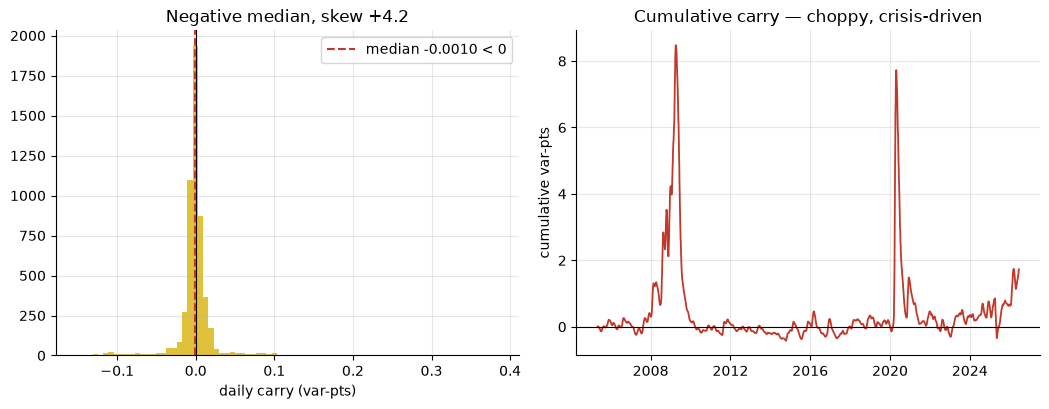

median -0.0010 (<0) | skew +4.2 | worst day -0.151 on 2009-06-09


In [5]:
if HAVE_REAL:
    x=PNL.values; x=x[np.isfinite(x)]; sk=PNL.skew(); md_=np.median(x); cum=PNL.cumsum()
    wdate=PNL.idxmin().date(); wd=PNL.min()
else:
    rng=np.random.default_rng(373); x=rng.standard_normal(5000)*0.01; sk=R['skew']; md_=R['median']; cum=None; wdate=R['worst_date']; wd=R['worst_day']
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.hist(x, bins=80, color=AMBER, alpha=.85); a1.axvline(0,c='k',lw=.8)
a1.axvline(md_, c=RED, ls='--', label=f'median {md_:.4f} < 0')
a1.set_title(f'Negative median, skew {sk:+.1f}'); a1.set_xlabel('daily carry (var-pts)'); a1.legend()
if HAVE_REAL:
    a2.plot(cum.index, cum.values, c=RED, lw=1.3); a2.axhline(0,c='k',lw=.8)
    a2.set_title('Cumulative carry — choppy, crisis-driven'); a2.set_ylabel('cumulative var-pts')
else:
    a2.text(.5,.5,'(cache absent)',ha='center')
plt.tight_layout(); plt.show()
print(f'median {md_:.4f} (<0) | skew {sk:+.1f} | worst day {wd:.3f} on {wdate}')

> 💡 In plain words: the **median day loses** (-0.0010); the positive mean is a **skew artefact** (+4.2). That is the textbook payoff of an **insurance seller** — small steady premium, rare large claim. The worst claim lands **2009-06-09** (GFC aftermath, correlations pinned near 1). You cannot size a NAV to a stream whose Sharpe is 0.1-ish *and* whose tail correlates with everything else blowing up. Tradability **MIRAGE**.

### 4e · Faithful-engine & planted-carry control — we know the truth here

On a deterministic one-factor correlated basket: with **zero** planted carry the mechanical gap is still positive ~100% of days, yet the carry must read **zero** (no false positive); with a planted carry it must light up. Both hold — proving the engine separates *identity* from *edge*.

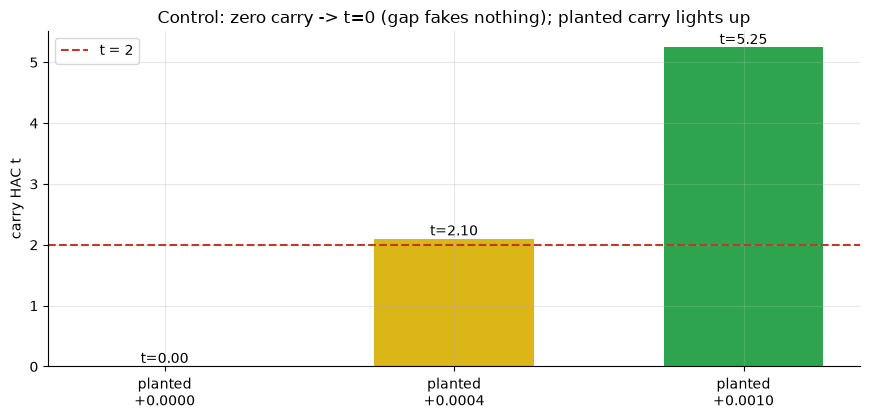

planted +0.0000: gap+=100% mean=+0.00000 Sharpe=0.00 HAC_t=0.00 p=0.502
planted +0.0004: gap+=100% mean=+0.00040 Sharpe=1.91 HAC_t=2.10 p=0.019
planted +0.0010: gap+=100% mean=+0.00100 Sharpe=4.78 HAC_t=5.25 p=0.000


In [6]:
res=[]
for carry in (0.0, 0.0004, 0.0010):
    syn=data.synthetic_basket(n_days=4000, n_names=40, carry=carry, seed=373)
    prox=data.dispersion_proxy(syn, window=21); gp=st.gap_sign_stats(prox)['share_positive']
    s=st.summarize_carry(st.synthetic_carry_pnl(syn))
    res.append((carry, gp*100, s['mean'], s['sharpe'], s['t_hac'], s['p_placebo']))
fig,ax=plt.subplots(figsize=(8.8,4.3))
labels=[f'planted\n{c:+.4f}' for c,_,_,_,_,_ in res]; tvals=[r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, AMBER, GREEN], width=.55)
ax.axhline(2, ls='--', c=RED, label='t = 2')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('carry HAC t'); ax.set_title('Control: zero carry -> t=0 (gap fakes nothing); planted carry lights up'); ax.legend()
plt.tight_layout(); plt.show()
for c,g,m,sh,t,p in res: print(f'planted {c:+.4f}: gap+={g:.0f}% mean={m:+.5f} Sharpe={sh:.2f} HAC_t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted carry the gap is positive **100%** of days yet the carry HAC *t* is **0.00** — **subadditivity manufactures the gap but zero edge.** A small planted carry just clears (HAC *t* = 2.10); a large one lights up (5.25). (Implied-correlation recovery is faithful too: planted ρ = 0.2/0.4/0.6 → measured 0.19/0.36/0.55.) So the machinery is honest, and the real-tape HAC *t* of ~0.2 is exactly what an **absent** carry looks like — the gap is identity, the carry is the correlation risk premium.

## 5 · The verdict

- **Signal `WEAK`** — the gap is real (+8 vol-pts, 100% of days) but **mechanical** (subadditivity); the carry that monetizes it is **HAC *t* = 0.19**, placebo *p* = 0.42, Sharpe 0.17. Identity + a positive-but-insignificant, autocorrelation-fragile carry ⇒ WEAK, not REAL (the desk's *t* ≥ 2 bar is not met). Survivorship biases the gap *narrower*, against the claim.
- **Tradability `MIRAGE`** — net Sharpe **0.15**; costs barely bite, but the carry is **negative-median, +4.2-skew** convexity whose tail (worst day 2009-06-09) is a correlation-spike crash. Not a NAV-scale, allocatable edge.
- **Free lunch? `BUSTED`** — the synthetic control nails it: **zero** planted carry, gap positive 100% of days, carry HAC *t* = 0.00. "Cheap" index vol is the **correlation risk premium** — priced compensation for short-correlation tail risk, not alpha.

## 6 · Could you trade it? — the power & premium curve

The operational truth in one picture: at our realized Sharpe and sample size, how big would the *true* carry have to be to clear t=2 — and where does the observed carry sit? The observed edge lives far below the detection floor, because what's left after the identity **is** the risk premium, not alpha.

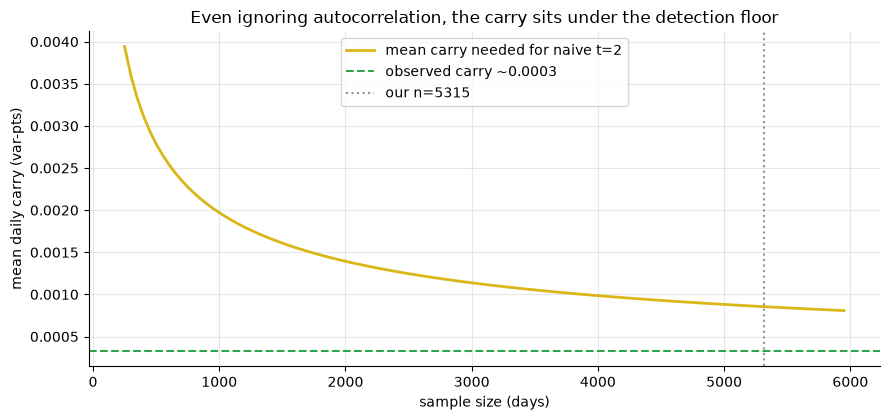

at n=5315, need ~0.00085 mean for naive t=2; observed ~0.00033 -> below the floor (and HAC makes it worse)


In [7]:
if HAVE_REAL:
    x=PNL.values; x=x[np.isfinite(x)]; sd=x.std(ddof=1); obs=x.mean(); n=len(x)
else:
    sd=0.012; obs=0.000325; n=R['n_carry']
# min detectable mean for naive t=2 at sample size k (illustrative; HAC inflates further)
ks=np.arange(250, 6000, 50)
min_det = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_det, c=AMBER, lw=2, label='mean carry needed for naive t=2')
ax.axhline(obs, c=GREEN, ls='--', label=f'observed carry ~{obs:.4f}')
ax.axvline(n, c=GREY, ls=':', label=f'our n={n}')
ax.set_xlabel('sample size (days)'); ax.set_ylabel('mean daily carry (var-pts)')
ax.set_title('Even ignoring autocorrelation, the carry sits under the detection floor'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(n)
print(f'at n={n}, need ~{need:.5f} mean for naive t=2; observed ~{obs:.5f} -> below the floor (and HAC makes it worse)')

> 💡 In plain words: the amber curve is the **minimum detectable carry**; the green line is what we observe. They don't meet at our sample — and that's *before* the HAC penalty for autocorrelation, which pushes the real bar higher still. There is no sizing, no window, no cost assumption that turns this into power, because the residual after the diversification identity is **the correlation risk premium** — compensation for a tail, not an exploitable edge. **The arithmetic that makes index vol "cheap" is exactly the arithmetic that makes the carry un-free.**

## 7 · Going further

- **Measure the premium directly.** With option-implied vols (or variance-swap quotes) you could compute the genuine **implied-minus-realized** dispersion spread — the actual carry source — and price the correlation risk premium (Driessen–Maenhout–Vilkov 2009) instead of proxying it with realized vol.
- **The index leg's implied vol.** [Study 03 — Fear-Gauge](../03-fear-gauge/) is the VIX, the implied index vol a dispersion trade sells.
- **Richer correlation model.** Replace equal weights with cap weights and the one-factor implied correlation with the full Σ; add a borrow charge on the single-name longs. The gap shrinks or grows, the **risk-premium conclusion does not.**

*The reproducible core is offline and deterministic; vol here is an explicit realized-vol proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*